# **2. Import libraries**

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from PIL import Image

# Preprocessing
from sklearn.model_selection import train_test_split as tts

# Torch
import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader
from torchinfo import summary
from torchvision.models import vit_b_16, ViT_B_16_Weights

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, classification_report

# Util
import os
from collections import OrderedDict
from tqdm.auto import tqdm
from pathlib import Path
import random
from typing import Dict, List
import warnings
warnings.filterwarnings("ignore")

# **3. Load data and EDA**

In [3]:
# Total Images
IMAGE_PATH = Path("../BackEnd/archive/files/")
IMAGE_PATH_LIST = list(IMAGE_PATH.glob("*/*/*.jpg"))
print(f'Total Images in Dataset = {len(IMAGE_PATH_LIST)}')

# Number of images per class.
classes = os.listdir(IMAGE_PATH)
classes = sorted(classes)

print("==" * 20)
print(" " * 10, f"Total Classes = {len(classes)}")
print("==" * 20)

for c in classes:
    total_images_class = list(Path(os.path.join(IMAGE_PATH, c)).glob("*/*.jpg"))
    print(f"* {c}: {len(total_images_class)} images")

Total Images in Dataset = 87
           Total Classes = 3
* acne: 30 images
* bags: 27 images
* redness: 30 images


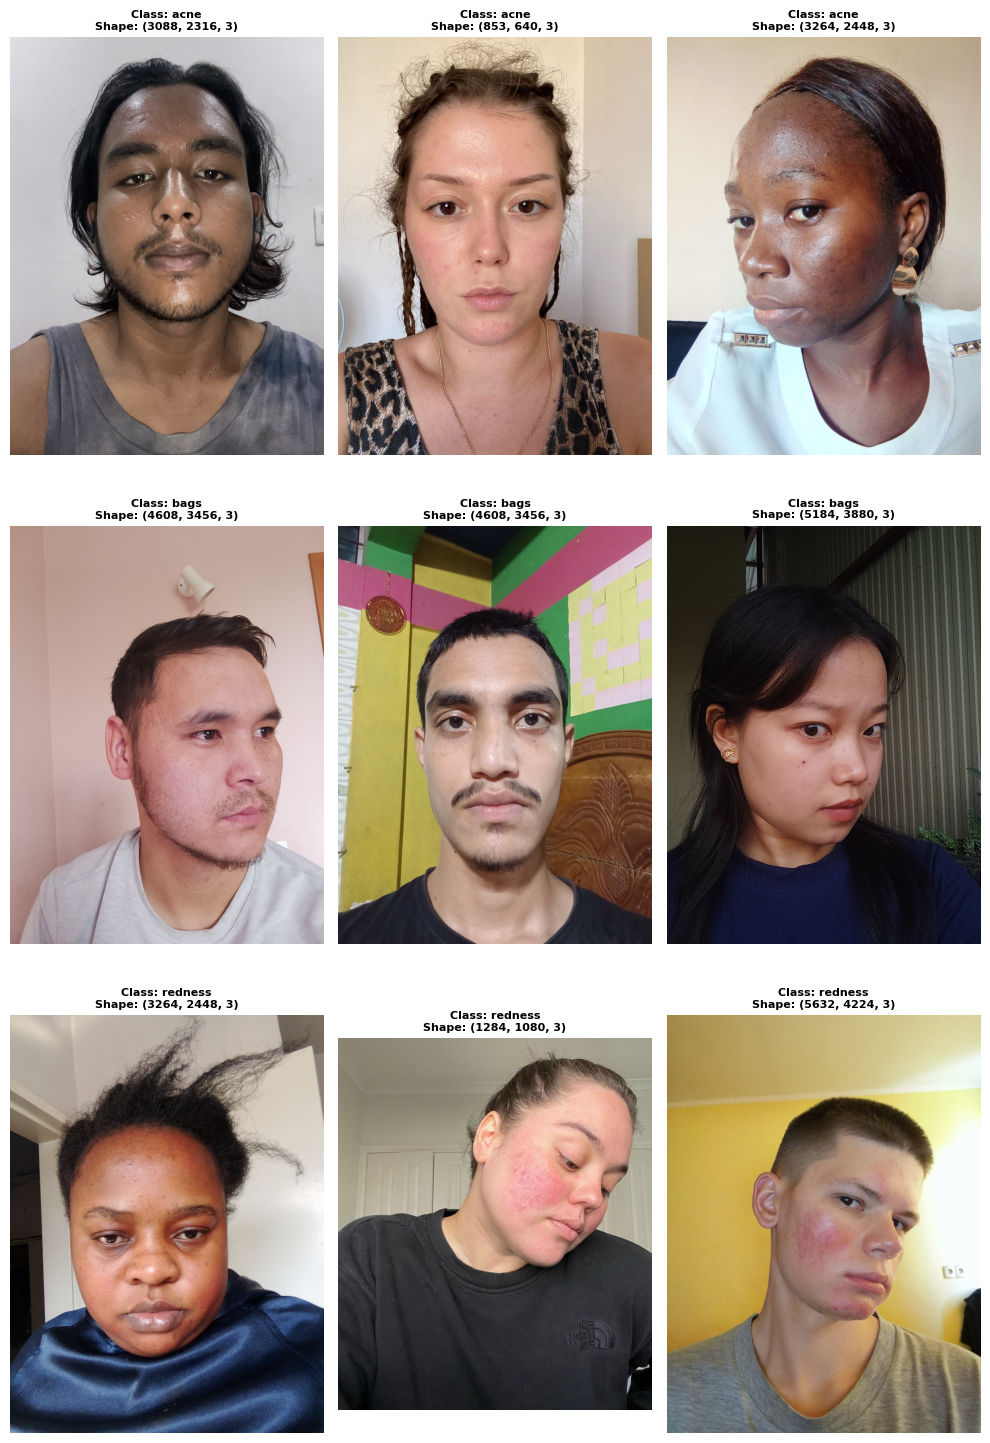

In [4]:
# Preview Some Images
NUM_IMAGES = 3

fig, ax = plt.subplots(nrows=len(classes), ncols=NUM_IMAGES, figsize=(10, 15))

for row, cls in enumerate(classes):
    image_paths = list((IMAGE_PATH / cls).glob("*/*.jpg"))
    selected_images = random.choices(image_paths, k=NUM_IMAGES)
    for col, img_path in enumerate(selected_images):
        img = cv2.imread(str(img_path))
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax[row, col].imshow(img_rgb)
        ax[row, col].axis("off")
        ax[row, col].set_title(
            f"Class: {cls}\nShape: {img_rgb.shape}",
            fontsize=8,
            fontweight="bold",
            color="black"
        )

fig.tight_layout()
plt.show()

# **4. Preprocessing**

Let's create a dataframe with two columns:

- the first **path** call will store the paths of the images.
- the second call **label** that will contain the labels of each image.

In [5]:
images_path = [None] * len(IMAGE_PATH_LIST)
labels = [None] * len(IMAGE_PATH_LIST)

for i,image_path in enumerate(IMAGE_PATH_LIST):
    images_path[i] = image_path
    labels[i] = image_path.parent.parent.stem
    
df_path_and_label = pd.DataFrame({'path':images_path, 
                                  'label':labels})
df_path_and_label.head()

,path,label
0,..\BackEnd\archive\files\acne\0\front.jpg,acne
1,..\BackEnd\archive\files\acne\0\left_side.jpg,acne
2,..\BackEnd\archive\files\acne\0\right_side.jpg,acne
3,..\BackEnd\archive\files\acne\1\front.jpg,acne
4,..\BackEnd\archive\files\acne\1\left_side.jpg,acne


Now we have to divide our dataframe into 3 parts:

- **train = 70%**
- **valid = 15%**
- **test = 15%**

In [6]:
SEED = 123 
# First train and rest - 70% and 30%
df_train, df_rest = tts(df_path_and_label, test_size = 0.3, random_state = SEED, stratify = df_path_and_label["label"])
# Then rest breaks down into val and test 15% and 15%
df_val, df_test = tts(df_rest, test_size = 0.5, random_state = SEED, stratify = df_rest["label"])

In [7]:
# We have to define the mapping of the classes to convert the labels to numbers.
label_map = dict(zip(classes, range(0, len(classes))))
label_map

{'acne': 0, 'bags': 1, 'redness': 2}

In [8]:
# Now we define the transformations that we are going to apply.
weights = ViT_B_16_Weights.DEFAULT # load weights from ViT_B_16
auto_transforms = weights.transforms() # sequence of image transformations (resize, crop, normalize) - tensor
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

Now we are going to create the **Dataset's** and **DataLoader's**.

Let's start with the **Dataset's**.

In [9]:
class CustomDataset(Dataset):
    def __init__(self, df:pd.DataFrame, transforms, label_map:dict):
        self.df = df
        self.transforms = transforms
        self.label_map = label_map
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        df_new = self.df.copy()
        df_new = df_new.reset_index(drop = True)
        df_new["label"] = df_new["label"].map(self.label_map)
        image_path = df_new.iloc[idx, 0]
        image = Image.open(image_path).convert("RGB")
        image = self.transforms(image)
        label = df_new.iloc[idx, 1]
        
        return image,label

In [10]:
train_dataset = CustomDataset(df_train, auto_transforms, label_map)
valid_dataset = CustomDataset(df_val, auto_transforms, label_map)

=> When we initialize CustomDataset -> DataLoader will call __getitem__ for each index to retrieve a transformed image and its mapped label 

**DataLoader's**

In [11]:
BATCH_SIZE = 32
NUM_WORKERS = 0  # Set to 0 for Windows compatibility (avoids multiprocessing issues)

train_dataloader = DataLoader(dataset = train_dataset, 
                              batch_size = BATCH_SIZE, 
                              shuffle = True, 
                              num_workers = NUM_WORKERS)
valid_dataloader = DataLoader(dataset = valid_dataset, 
                              batch_size = BATCH_SIZE, 
                              shuffle = True, 
                              num_workers = NUM_WORKERS)

In [12]:
# Let's visualize the dimensions of a batch.
batch_images, batch_labels = next(iter(train_dataloader))
batch_images.shape, batch_labels.shape

(torch.Size([32, 3, 224, 224]), torch.Size([32]))

# **5. Model**

In [13]:
# GPU checking
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [14]:
# We define the model to use with the pre-trained weights.
model = vit_b_16(weights = weights)

In [15]:
# Visualize the architecture of the model.
summary(model = model, 
        input_size = [1, 3, 224, 224], 
        col_names = ["input_size", "output_size", "num_params", "trainable"], 
        col_width = 15, 
        row_settings = ["var_names"])

Layer (type (var_name))                                      Input Shape     Output Shape    Param #         Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224] [1, 1000]       768             True
├─Conv2d (conv_proj)                                         [1, 3, 224, 224] [1, 768, 14, 14] 590,592         True
├─Encoder (encoder)                                          [1, 197, 768]   [1, 197, 768]   151,296         True
│    └─Dropout (dropout)                                     [1, 197, 768]   [1, 197, 768]   --              --
│    └─Sequential (layers)                                   [1, 197, 768]   [1, 197, 768]   --              True
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]   [1, 197, 768]   7,087,872       True
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]   [1, 197, 768]   7,087,872       True
│    │    └─EncoderBlock (encoder_layer_2)                   [1, 197, 768]   [1, 1

In [16]:
#Freeze all params conv_proj
for param in model.conv_proj.parameters():
    param.requires_grad = False

#Freeze all params encoder layers
for param in model.encoder.parameters():
    param.requires_grad = False

In [17]:
# Let's see if the parameters were frozen.
summary(model = model, 
        input_size = [1,3,224,224], 
        col_names = ["input_size", "output_size", "num_params", "trainable"], 
        col_width = 15,
        row_settings = ["var_names"])

Layer (type (var_name))                                      Input Shape     Output Shape    Param #         Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224] [1, 1000]       768             Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224] [1, 768, 14, 14] (590,592)       False
├─Encoder (encoder)                                          [1, 197, 768]   [1, 197, 768]   151,296         False
│    └─Dropout (dropout)                                     [1, 197, 768]   [1, 197, 768]   --              --
│    └─Sequential (layers)                                   [1, 197, 768]   [1, 197, 768]   --              False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]   [1, 197, 768]   (7,087,872)     False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]   [1, 197, 768]   (7,087,872)     False
│    │    └─EncoderBlock (encoder_layer_2)                   [1, 197, 768]

In [18]:
# Change the output classes 
output_shape = len(classes)
model.heads = nn.Sequential(OrderedDict([('head', nn.Linear(in_features = 768, 
                                                            out_features = output_shape))]))

In [19]:
# One last time let's take a look if the last layer was modified.
summary(model = model, 
        input_size = [1,3,224,224], 
        col_names = ["input_size", "output_size", "num_params", "trainable"], 
        col_width = 15,
        row_settings = ["var_names"])

Layer (type (var_name))                                      Input Shape     Output Shape    Param #         Trainable
VisionTransformer (VisionTransformer)                        [1, 3, 224, 224] [1, 3]          768             Partial
├─Conv2d (conv_proj)                                         [1, 3, 224, 224] [1, 768, 14, 14] (590,592)       False
├─Encoder (encoder)                                          [1, 197, 768]   [1, 197, 768]   151,296         False
│    └─Dropout (dropout)                                     [1, 197, 768]   [1, 197, 768]   --              --
│    └─Sequential (layers)                                   [1, 197, 768]   [1, 197, 768]   --              False
│    │    └─EncoderBlock (encoder_layer_0)                   [1, 197, 768]   [1, 197, 768]   (7,087,872)     False
│    │    └─EncoderBlock (encoder_layer_1)                   [1, 197, 768]   [1, 197, 768]   (7,087,872)     False
│    │    └─EncoderBlock (encoder_layer_2)                   [1, 197, 768]

In [20]:
# Loss and Optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01)

We are going to define 3 functions for training and one to store the best model:

- **train_step**
- **save_checkpoint**
- **valid_step**
- **train**

In [21]:
def train_step(model:torch.nn.Module, 
               dataloader:torch.utils.data.DataLoader, 
               loss_fn:torch.nn.Module, 
               optimizer:torch.optim.Optimizer):
    
    model.train()
    
    train_loss = 0.
    train_accuracy = 0.
    
    for batch,(X,y) in enumerate(dataloader): # load a batch
        X,y = X.to(device), y.to(device) # move to GPU or CPU
        optimizer.zero_grad() # reset gradients
        y_pred_logit = model(X) # forward 
        loss = loss_fn(y_pred_logit, y) # batch loss calculate
        train_loss += loss.item() # total loss
        
        loss.backward() # compute gradients
        optimizer.step() # optimize params
        
        y_pred_prob = torch.softmax(y_pred_logit, dim = 1) # turn logits into prob distribution 
        y_pred_class = torch.argmax(y_pred_prob, dim = 1) # true class
        train_accuracy += accuracy_score(y.cpu().numpy(), 
                                         y_pred_class.detach().cpu().numpy())
        
    train_loss = train_loss/len(dataloader) # average training loss 
    train_accuracy = train_accuracy/len(dataloader) # average training acc
    
    return train_loss, train_accuracy

In [22]:
def save_checkpoint(filename, model, loss, epoch, optimizer, metric):
    state = {"filename":filename, 
             "model":model.state_dict(), 
             "loss":loss, 
             "epoch":epoch, 
             "optimizer":optimizer.state_dict(), 
             "metric":metric}
    
    torch.save(state, filename)

In [23]:
def valid_step(model:torch.nn.Module, 
               dataloader:torch.utils.data.DataLoader, 
               loss_fn:torch.nn.Module): # run one full epoch over validation set -> traking avg loss and acc
    
    model.eval()
    
    valid_loss = 0.
    valid_accuracy = 0.
    
    with torch.inference_mode():
        for batch,(X,y) in enumerate(dataloader):
            X,y = X.to(device), y.to(device)
            y_pred_logit = model(X)
            loss = loss_fn(y_pred_logit, y)
            valid_loss += loss.item()
            
            y_pred_prob = torch.softmax(y_pred_logit, dim = 1)
            y_pred_class = torch.argmax(y_pred_prob, dim = 1)
            
            valid_accuracy += accuracy_score(y.cpu().numpy(), y_pred_class.detach().cpu().numpy())
            
    valid_loss = valid_loss/len(dataloader)
    valid_accuracy = valid_accuracy/len(dataloader)
    
    return valid_loss, valid_accuracy

In [24]:
def train(model:torch.nn.Module, 
          train_dataloader:torch.utils.data.DataLoader, 
          valid_dataloader:torch.utils.data.DataLoader, 
          loss_fn:torch.nn.Module, 
          optimizer:torch.optim.Optimizer, 
          epochs:int = 10):
    
    results = {"train_loss":[], 
               "train_accuracy":[], 
               "valid_loss":[], 
               "valid_accuracy":[]}
    
    best_valid_loss = float("inf")
    
    for epoch in tqdm(range(epochs)):
        train_loss, train_accuracy = train_step(model = model, 
                                                dataloader = train_dataloader, 
                                                loss_fn = loss_fn, 
                                                optimizer = optimizer)
        
        valid_loss, valid_accuracy = valid_step(model = model, 
                                                dataloader = valid_dataloader, 
                                                loss_fn = loss_fn)
        
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            file_name = "best_model.pth"
            save_checkpoint(file_name, model, best_valid_loss, epoch, optimizer, valid_accuracy)
            
        print(f"Epoch: {epoch + 1} | ", 
              f"Train Loss: {train_loss:.4f} | ", 
              f"Train Accuracy: {train_accuracy:.4f} | ", 
              f"Valid Loss: {valid_loss:.4f} | ", 
              f"Valid Accuracy: {valid_accuracy:.4f}")
        
        results["train_loss"].append(train_loss)
        results["train_accuracy"].append(train_accuracy)
        results["valid_loss"].append(valid_loss)
        results["valid_accuracy"].append(valid_accuracy)
        
    return results

In [25]:
# Training
EPOCHS = 100

torch.cuda.manual_seed(SEED)
torch.manual_seed(SEED)

MODEL_RESULTS = train(model.to(device), 
                      train_dataloader, 
                      valid_dataloader, 
                      loss_fn, 
                      optimizer, 
                      EPOCHS)

  1%|          | 1/100 [00:09<16:19,  9.89s/it]

Epoch: 1 |  Train Loss: 1.1276 |  Train Accuracy: 0.3906 |  Valid Loss: 1.0056 |  Valid Accuracy: 0.6154


  2%|▏         | 2/100 [00:19<16:02,  9.82s/it]

Epoch: 2 |  Train Loss: 0.5746 |  Train Accuracy: 0.7924 |  Valid Loss: 0.6001 |  Valid Accuracy: 0.6154


  3%|▎         | 3/100 [00:29<16:08,  9.98s/it]

...

Epoch: 98 |  Train Loss: 0.0003 |  Train Accuracy: 1.0000 |  Valid Loss: 0.0844 |  Valid Accuracy: 0.9231


 99%|█████████▉| 99/100 [15:54<00:09,  9.66s/it]

Epoch: 99 |  Train Loss: 0.0003 |  Train Accuracy: 1.0000 |  Valid Loss: 0.0843 |  Valid Accuracy: 0.9231


100%|██████████| 100/100 [16:03<00:00,  9.64s/it]

Epoch: 100 |  Train Loss: 0.0003 |  Train Accuracy: 1.0000 |  Valid Loss: 0.0840 |  Valid Accuracy: 0.9231


In [26]:
# Function to plot the loss and metric during each training epoch.
def loss_metric_curve_plot(model_results:Dict[str,List[float]]):
    
    train_loss = model_results["train_loss"]
    valid_loss = model_results["valid_loss"]
    
    train_accuracy = [float(value) for value in model_results["train_accuracy"]]
    valid_accuracy = [float(value) for value in model_results["valid_accuracy"]]
    
    fig,axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))
    axes = axes.flat
    
    axes[0].plot(train_loss, color = "red", label = "Train")
    axes[0].plot(valid_loss, color = "blue", label = "Valid")
    axes[0].set_title("CrossEntropyLoss", fontsize = 12, fontweight = "bold", color = "black")
    axes[0].set_xlabel("Epochs", fontsize = 10, fontweight = "bold", color = "black")
    axes[0].set_ylabel("Loss", fontsize = 10, fontweight = "bold", color = "black")
    axes[0].legend()
    
    axes[1].plot(train_accuracy, color = "red", label = "Train")
    axes[1].plot(valid_accuracy, color = "blue", label = "Valid")
    axes[1].set_title("Metric of performance: Accuracy", fontsize = 12, fontweight = "bold", color = "black")
    axes[1].set_xlabel("Epochs", fontsize = 10, fontweight = "bold", color = "black")
    axes[1].set_ylabel("Score", fontsize = 10, fontweight = "bold", color = "black")
    axes[1].legend()
    
    fig.tight_layout()
    fig.show()

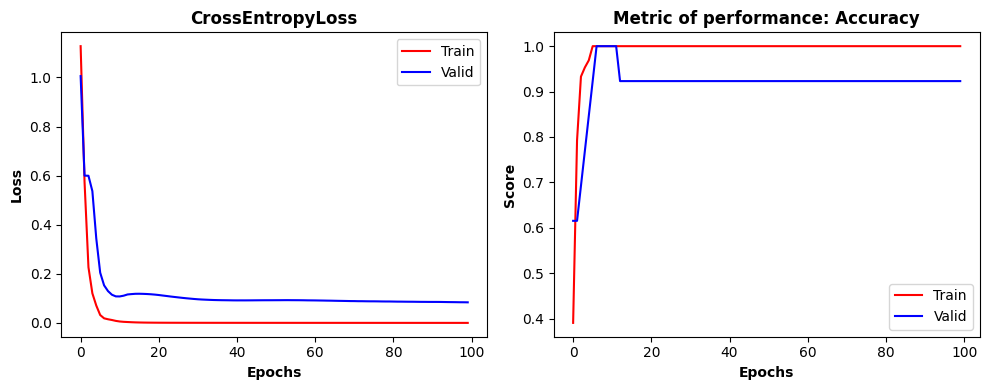

In [27]:
loss_metric_curve_plot(MODEL_RESULTS)

In [28]:
# Let's load the best model.
checkpoint_path = "best_model.pth"
checkpoint = torch.load(checkpoint_path, map_location=device)

In [29]:
# Now let's look at the smallest loss, its metric and when it occurred.
print(f'Best Loss: {checkpoint["loss"]}')
print(f'Epoch: {checkpoint["epoch"] + 1}')
print(f'Best Metric: {checkpoint["metric"]}')

Best Loss: 0.08404885977506638
Epoch: 100
Best Metric: 0.9230769230769231


Well, now we have to predict the images of the test set.

- **Predictions**

In [30]:
# First of all, we create the Dataset, DataLoader
test_dataset = CustomDataset(df_test, auto_transforms, label_map)
test_dataloader = DataLoader(dataset = test_dataset, shuffle = False, num_workers = 0)

In [31]:
# We define the model again with its respective modification.
loaded_model = vit_b_16()

loaded_model.heads = nn.Sequential(OrderedDict([('head',nn.Linear(in_features = 768, 
                                                                  out_features = output_shape))]))

loaded_model.load_state_dict(checkpoint["model"])

# We now infer
loaded_model.to(device)

loaded_model.eval()

y_pred_test = []

with torch.inference_mode():
    for X,y in tqdm(test_dataloader):
        X,y = X.to(device), y.to(device)
        y_pred_logit = loaded_model(X)
        y_pred_prob = torch.softmax(y_pred_logit, dim = 1)
        y_pred_class = torch.argmax(y_pred_prob, dim = 1)
        y_pred_test.append(y_pred_class.detach().cpu())

100%|██████████| 14/14 [00:01<00:00,  8.73it/s]


In [32]:
y_pred_test = torch.cat(y_pred_test).numpy()

# **6. Metrics**

- **Accuracy**

In [33]:
print(f'Accuracy = {round(accuracy_score(df_test["label"].map(label_map), y_pred_test), 4)}')

Accuracy = 0.8571


- **Confusion Matrix**

In [34]:
confusion_matrix_test = confusion_matrix(df_test["label"].map(label_map), y_pred_test)

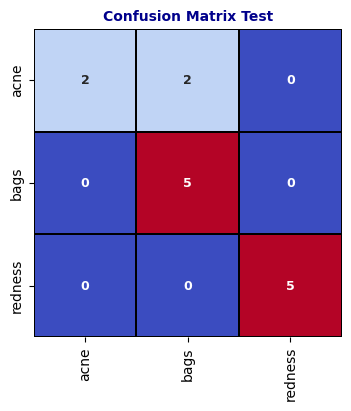

In [35]:
fig,ax = plt.subplots(figsize = (15,4))
sns.heatmap(confusion_matrix_test, 
            cmap = 'coolwarm', 
            annot = True, 
            annot_kws = {"fontsize":9, "fontweight":"bold"}, 
            linewidths = 1.2, 
            linecolor = "black", 
            square = True, 
            xticklabels = classes, 
            yticklabels = classes, 
            cbar = False,
            ax = ax)
ax.set_title("Confusion Matrix Test", fontsize = 10, fontweight = "bold", color = "darkblue")
ax.tick_params('x',rotation = 90)
fig.show()